# **Практическая работа №10. Пространственный анализ доступности социальной инфраструктуры с использованием OpenStreetMap**

## **Цель работы**

Овладеть методами пространственного анализа городских территорий на основе открытых геоданных: загрузка данных из OpenStreetMap, конструирование пространственных признаков и их визуализация на тепловых картах административных районов и гексагональной H3‑сетки.

## **Введение**

Доступность социальной инфраструктуры (школы, детские сады, поликлиники, общественный транспорт и т.п.) является базовой характеристикой качества городской среды. Современные методы геоанализа позволяют количественно оценивать уровень такой доступности для разных участков города и визуализировать результаты в удобной для интерпретации форме.

В данной практической работе вы выполните полный цикл пространственного анализа: от выбора территории и постановки исследовательской задачи до расчёта интегрального показателя доступности и построения тепловых карт по районам и гексагональной ячейке.

## **Задание**

Провести пространственное исследование уровня доступности социальной инфраструктуры для жителей выбранной городской территории, используя данные OpenStreetMap, и визуализировать результаты:

- на карте административных районов;
- на гексагональной H3‑сетке.

---

## **Порядок выполнения работы**

### **Часть 1. Подготовка данных и постановка задачи**

1. **Выбор территории и фокуса исследования**

   - Выберите город и область интереса (ROI) для анализа:
     - это может быть весь город или его часть (например, центральные районы, спальный район, новая застройка).
   - Определите фокус исследования:
     - например:
       - доступность школ и детских садов;
       - доступность поликлиник и больниц;
       - комплексная доступность нескольких типов объектов (школы + сады + поликлиники + остановки ОТ).
   - Кратко обоснуйте выбор:
     - почему вы выбрали именно эту территорию;
     - почему выбранный фокус социальной инфраструктуры важен и интересен для анализа.

### Территория исследования (ROI)

Город: **Казань**

Для анализа выбрана **центральная часть города** с радиусом **1.5 км** от центра.  
Центральные районы характеризуются высокой плотностью населения, смешанной жилой и общественной застройкой и высокой концентрацией объектов социальной инфраструктуры.


### Фокус исследования

Исследуется **доступность объектов социальной инфраструктуры** для жителей выбранной территории.

Типы объектов (OpenStreetMap `amenity`):

```python
amenities = {
    'amenity': ['school', 'kindergarten', 'clinic', 'hospital']
}

### Обоснование 

Казань — крупный город с разнообразной городской структурой и высокой плотностью населения. Анализ доступности образовательных и медицинских учреждений в радиусе 1.5 км позволяет оценить уровень обеспеченности жителей базовой социальной инфраструктурой и выявить возможные зоны с недостаточной доступностью.

2. **Определение признаков доступности**

   - Сформулируйте **не менее 5 признаков**, которые, по вашему мнению, характеризуют доступность социальной инфраструктуры для жителей. Примеры признаков:
     - количество объектов нужного типа в шаговой доступности;
     - средняя удалённость до ближайшего объекта;
     - наличие альтернативных видов инфраструктуры (например, частные и государственные школы);
     - транспортная доступность (наличие остановок общественного транспорта поблизости);
     - обеспеченность зелёными зонами рядом с социальной инфраструктурой (парки возле школ и т.п.).
   - Для каждого признака определите, **какими тегами OpenStreetMap** его можно описать. Примеры тегов:
     - `amenity=school`, `amenity=kindergarten`, `amenity=clinic`, `amenity=hospital`;
     - `highway=bus_stop`, `railway=subway_entrance`;
     - `leisure=park`, `leisure=pitch`;
     - границы районов: `boundary=administrative`, `admin_level=*`.
   - Составьте **таблицу соответствия**:

     | признак                     | Описание признака                             | OSM‑теги / атрибуты                       |
     |----------------------------|----------------------------------------------|-------------------------------------------|
     | Кол-во школ в шаговой доступности | Школы в радиусе 800 м от ячейки/района | `amenity=school`                          |
     | Наличие детских садов      | Детсады в радиусе 600 м                     | `amenity=kindergarten`                    |
     | Транспортная доступность   | Остановки ОТ в радиусе 400 м                | `highway=bus_stop`, `railway=tram_stop`   |
     | Близость метро             | Минимальное расстояние до метро             | `railway=subway_entrance`                 |
     | Наличие зелёных зон        | Площадь парков в радиусе 800 м              | `leisure=park`                            |


| Признак | Описание признака | OSM-теги / атрибуты |
|---|---|---|
| Количество медицинских объектов | Число клиник и больниц в радиусе **800 м** от ячейки | `amenity=clinic`, `amenity=hospital` |
| Количество образовательных объектов | Число школ и детских садов в радиусе **800 м** | `amenity=school`, `amenity=kindergarten` |
| Минимальное расстояние до ближайшей школы | Расстояние от центра ячейки до ближайшей школы | `amenity=school` |
| Минимальное расстояние до ближайшего медицинского учреждения | Расстояние до ближайшей клиники или больницы | `amenity=clinic`, `amenity=hospital` |
| Общее количество объектов социальной инфраструктуры | Суммарное число школ, детских садов, клиник и больниц в радиусе **1 км** | `amenity=school`, `amenity=kindergarten`, `amenity=clinic`, `amenity=hospital` |




3. **Сбор исходных данных из OpenStreetMap**

   - Настройте необходимые библиотеки (по аналогии с примером):  
     `osmnx`, `geopandas`, `h3`, `h3pandas`, `leafmap`, `shapely`, `pandas`, `numpy` и др.
   - С помощью интерактивной карты (`leafmap.Map` и инструмент рисования) определите **bounding box** или полигон области интереса.
   - Загрузите из OSM с помощью `osmnx.features_from_bbox()` (или аналогичных функций):
     - объекты социальной инфраструктуры, соответствующие вашим признакам;
     - слои, отражающие административные границы районов (или муниципальных округов).

   - Приведите все пространственные слои к единой системе координат (например, `EPSG:3857` для метрических расчётов).



In [ ]:
# %pip install osmnx geopandas h3 h3pandas leafmap shapely pandas numpy pyproj

import osmnx as ox
import geopandas as gpd
import pandas as pd
import numpy as np
from shapely.geometry import Point, box, Polygon
import h3

ox.settings.use_cache = True
ox.settings.log_console = True

In [2]:
# Центр Казани
center_lat = 55.7963
center_lon = 49.1088

# Радиус области анализа
dist_m = 1500  # 1.5 км

# Точка центра
center_point = gpd.GeoDataFrame(
    geometry=[Point(center_lon, center_lat)],
    crs="EPSG:4326"
)

# Перевод в метры и построение буфера
center_point_3857 = center_point.to_crs(epsg=3857)
buffer_geom = center_point_3857.buffer(dist_m).iloc[0]

# Обратно в WGS84
buffer_wgs84 = gpd.GeoSeries([buffer_geom], crs="EPSG:3857").to_crs(epsg=4326).iloc[0]

# Bounding box
west, south, east, north = buffer_wgs84.bounds

print(f"north={north}, south={south}, east={east}, west={west}")

north=55.80387390439652, south=55.78872462231354, east=49.1222747292618, west=49.09532527073821


In [3]:
# Теги социальной инфраструктуры
tags_infra = {
    "amenity": ["school", "kindergarten", "clinic", "hospital"]
}

# Загрузка объектов инфраструктуры
gdf_infra = ox.features_from_bbox(
    bbox=(west, south, east, north),
    tags=tags_infra
)

print("Размер gdf_infra:", gdf_infra.shape)
display(gdf_infra.head())

Размер gdf_infra: (27, 49)


geometry   amenity  \
element id                                                
node    2492065423   POINT (49.10451 55.7937)    school   
        4103496605  POINT (49.12162 55.79629)    clinic   
        5068986579   POINT (49.12179 55.7971)  hospital   
        5069054279  POINT (49.12115 55.79703)  hospital   
        7832351406  POINT (49.11765 55.79079)  hospital   

                                                 name  ref addr:city  \
element id                                                             
node    2492065423                          Школа № 1    1       NaN   
        4103496605              Поликлиника МВД по РТ  NaN    Казань   
        5068986579  Медико-санитарная часть МВД по РТ  NaN    Казань   
        5069054279          Военно-врачебная комиссия  NaN    Казань   
        7832351406                        Скандинавия  NaN       NaN   

                   addr:housenumber         addr:street healthcare  \
element id                                                           
node    2492065423              NaN                 NaN        NaN   
        4103496605                9  улица Лобачевского     clinic   
        5068986579               13  улица Лобачевского   hospital   
        5069054279               13  улица Лобачевского   hospital   
        7832351406              NaN                 NaN     clinic   

                                            phone  \
element id                                          
node    2492065423                            NaN   
        4103496605  +7 843 2913693;+7 843 2913051   
        5068986579                 +7 843 2912139   
        5069054279                 +7 843 2912139   
        7832351406                            NaN   

                                                              website  ...  \
element id                                                             ...   
node    2492065423                                                NaN  ...   
        4103496605   https://мсч.16.мвд.рф/Podrazdeleniya/Poliklinika  ...   
        5068986579                                                NaN  ...   
        5069054279  https://мсч.16.мвд.рф/Podrazdeleniya/Voenno_vr...  ...   
        7832351406                                                NaN  ...   

                   education_system:ru_standard isced:level official_name  \
element id                                                                  
node    2492065423                          NaN         NaN           NaN   
        4103496605                          NaN         NaN           NaN   
        5068986579                          NaN         NaN           NaN   
        5069054279                          NaN         NaN           NaN   
        7832351406                          NaN         NaN           NaN   

                   official_name:tt type building building:levels layer  \
element id                                                                
node    2492065423              NaN  NaN      NaN             NaN   NaN   
        4103496605              NaN  NaN      NaN             NaN   NaN   
        5068986579              NaN  NaN      NaN             NaN   NaN   
        5069054279              NaN  NaN      NaN             NaN   NaN   
        7832351406              NaN  NaN      NaN             NaN   NaN   

                   wikidata wikipedia  
element id                             
node    2492065423      NaN       NaN  
        4103496605      NaN       NaN  
        5068986579      NaN       NaN  
        5069054279      NaN       NaN  
        7832351406      NaN       NaN  

[5 rows x 49 columns]

In [4]:
# Теги административных границ
tags_admin = {
    "boundary": "administrative"
}

# Загрузка границ из OSM
gdf_admin = ox.features_from_bbox(
    bbox=(west, south, east, north),
    tags=tags_admin
)

# Если нужен альтернативный порядок координат:
# gdf_admin = ox.features_from_bbox((north, south, east, west), tags=tags_admin)

# Оставим только объекты с геометрией
gdf_infra = gdf_infra[gdf_infra.geometry.notnull()].copy()
gdf_admin = gdf_admin[gdf_admin.geometry.notnull()].copy()

# Приведение к единой системе координат
gdf_infra_3857 = gdf_infra.to_crs(epsg=3857)
gdf_admin_3857 = gdf_admin.to_crs(epsg=3857)

print("gdf_infra_3857:", gdf_infra_3857.shape)
print("gdf_admin_3857:", gdf_admin_3857.shape)
display(gdf_admin_3857.head())

gdf_infra_3857: (27, 49)
gdf_admin_3857: (7, 65)


geometry  \
element  id                                                           
relation 79374    MULTIPOLYGON (((5259057.542 7332513.079, 52593...   
         367666   POLYGON ((5436738.511 7515863.267, 5436745.88 ...   
         2133462  POLYGON ((5456044.672 7508509.386, 5456571.303...   
         2133463  POLYGON ((5436738.511 7515863.267, 5436745.88 ...   
         2133464  POLYGON ((5446534.993 7533263.593, 5446582.961...   

                 admin_level border_type        boundary  \
element  id                                                
relation 79374             4      region  administrative   
         367666            6         NaN  administrative   
         2133462           9         NaN  administrative   
         2133463           9         NaN  administrative   
         2133464           9         NaN  administrative   

                                    name     name:ja                 name:ru  \
element  id                                                                    
relation 79374                 Татарстан  タタールスタン共和国               Татарстан   
         367666   городской округ Казань         NaN  городской округ Казань   
         2133462       Вахитовский район         NaN       Вахитовский район   
         2133463         Кировский район         NaN         Кировский район   
         2133464        Московский район         NaN        Московский район   

                              name:tt  wikidata                     wikipedia  \
element  id                                                                     
relation 79374              Татарстан     Q5481                  ru:Татарстан   
         367666   Казан шәһәр бүлгесе      Q900                     ru:Казань   
         2133462                  NaN  Q4105370          ru:Вахитовский район   
         2133463                  NaN  Q4221678   ru:Кировский район (Казань)   
         2133464                  NaN  Q4304266  ru:Московский район (Казань)   

                  ... name:zh-Hans name:zh-Hant         official_name  \
element  id       ...                                                   
relation 79374    ...      鞑靼斯坦共和国      韃靼斯坦共和國  Республика Татарстан   
         367666   ...          NaN          NaN                   NaN   
         2133462  ...          NaN          NaN                   NaN   
         2133463  ...          NaN          NaN                   NaN   
         2133464  ...          NaN          NaN                   NaN   

                    official_name:sk oktmo:user population population:date  \
element  id                                                                  
relation 79374    Tatárska republika   92000000    4001625            2023   
         367666                  NaN        NaN    1216965             NaN   
         2133462                 NaN        NaN        NaN             NaN   
         2133463                 NaN        NaN        NaN             NaN   
         2133464                 NaN        NaN        NaN             NaN   

                    ref   wikimedia_commons     official_status  
element  id                                                      
relation 79374    RU-TA  Category:Tatarstan                 NaN  
         367666     NaN                 NaN  ru:городской округ  
         2133462    NaN                 NaN                 NaN  
         2133463    NaN                 NaN                 NaN  
         2133464    NaN                 NaN                 NaN  

[5 rows x 65 columns]

In [5]:
# Оставим только нужные типы инфраструктуры
gdf_infra_3857 = gdf_infra_3857[
    gdf_infra_3857["amenity"].isin(["school", "kindergarten", "clinic", "hospital"])
].copy()

# Для административных границ оставим только полигоны
gdf_admin_3857 = gdf_admin_3857[
    gdf_admin_3857.geometry.geom_type.isin(["Polygon", "MultiPolygon"])
].copy()

# Часто полезно оставить только уровни admin_level, если они есть
if "admin_level" in gdf_admin_3857.columns:
    gdf_admin_3857 = gdf_admin_3857[
        gdf_admin_3857["admin_level"].notna()
    ].copy()

print("Инфраструктура:")
print(gdf_infra_3857[["amenity", "geometry"]].head())

print("\nАдминистративные границы:")
cols = [c for c in ["name", "boundary", "admin_level", "geometry"] if c in gdf_admin_3857.columns]
display(gdf_admin_3857[cols].head())

Инфраструктура:
                     amenity                         geometry
element id                                                   
node    2492065423    school  POINT (5466288.748 7517456.972)
        4103496605    clinic  POINT (5468193.202 7517969.257)
        5068986579  hospital  POINT (5468212.516 7518129.622)
        5069054279  hospital  POINT (5468141.093 7518116.037)
        7832351406  hospital    POINT (5467751.52 7516879.48)

Административные границы:


name        boundary admin_level  \
element  id                                                            
relation 79374                 Татарстан  administrative           4   
         367666   городской округ Казань  administrative           6   
         2133462       Вахитовский район  administrative           9   
         2133463         Кировский район  administrative           9   
         2133464        Московский район  administrative           9   

                                                           geometry  
element  id                                                          
relation 79374    MULTIPOLYGON (((5259057.542 7332513.079, 52593...  
         367666   POLYGON ((5436738.511 7515863.267, 5436745.88 ...  
         2133462  POLYGON ((5456044.672 7508509.386, 5456571.303...  
         2133463  POLYGON ((5436738.511 7515863.267, 5436745.88 ...  
         2133464  POLYGON ((5446534.993 7533263.593, 5446582.961...

---

### **Часть 2. Пространственное агрегирование и инженерия признаков**

1. **Построение гексагональной H3‑сетki**

   - Определите подходящее **разрешение (resolution)** H3‑сетки для вашей территории:
     - маленькое значение (5–7) — крупные ячейки для больших территорий;
     - большое значение (8–10 и выше) — более детальный анализ на уровне кварталов/микрорайонов.
   - Обоснуйте ваш выбор resolution с точки зрения:
     - размера города или ROI;
     - характера объектов (шаговая доступность, плотность застройки);
     - удобства визуализации и интерпретации.
   - Сгенерируйте H3‑индексы, покрывающие выбранный полигон (через `h3.polyfill_geojson`), и создайте `GeoDataFrame` с геометриями ячеек.

### Выбор разрешения H3-сетки

Для исследуемой территории выбрано разрешение **H3 resolution = 9**.

Это значение подходит для анализа центральной части Казани в радиусе 1.5 км, так как:
- ячейки получаются достаточно мелкими для городского анализа;
- сетка позволяет отразить локальные различия в доступности школ, детских садов и медицинских учреждений;
- визуализация остаётся читаемой и удобной для интерпретации.

Таким образом, `resolution = 9` обеспечивает баланс между детализацией анализа и наглядностью итоговой карты.

In [ ]:
# ROI в формате GeoDataFrame
roi_gdf = gpd.GeoDataFrame(
    geometry=[buffer_geom],
    crs="EPSG:3857"
).to_crs(epsg=4326)

# Геометрия полигона в GeoJSON-like формате
roi_geom = roi_gdf.geometry.iloc[0]
roi_geojson = roi_geom.__geo_interface__

# Параметр H3
resolution = 9

# Получаем H3-ячейки
hex_ids = h3.polyfill_geojson(roi_geojson, resolution)

print(f"Количество H3-ячеек: {len(hex_ids)}")
list(hex_ids)[:5]

Количество H3-ячеек: 20


['8910a810567ffff',
 '8910a8101cfffff',
 '8910a81019bffff',
 '8910a8101d7ffff',
 '8910a810153ffff']

In [ ]:
hex_polygons = []

for hex_id in hex_ids:
    boundary = h3.h3_to_geo_boundary(hex_id)
    polygon = Polygon([(lng, lat) for lat, lng in boundary])
    
    hex_polygons.append({
        "h3_id": hex_id,
        "geometry": polygon
    })

hex_gdf = gpd.GeoDataFrame(hex_polygons, crs="EPSG:4326")

# перевод в метры
hex_gdf_3857 = hex_gdf.to_crs(epsg=3857)

print(hex_gdf_3857.shape)
display(hex_gdf_3857.head())

(20, 2)


,h3_id,geometry
0,8910a810567ffff,"POLYGON ((5465377.481 7518857.671, 5465628.174..."
1,8910a8101cfffff,"POLYGON ((5466881.454 7517290.824, 5467132.073..."
2,8910a81019bffff,"POLYGON ((5465981.066 7518697.345, 5466231.743..."
3,8910a8101d7ffff,"POLYGON ((5466129.524 7518074.266, 5466380.179..."
4,8910a810153ffff,"POLYGON ((5467029.828 7516667.802, 5467280.425..."


In [10]:
# ROI в EPSG:3857
roi_3857 = gpd.GeoDataFrame(
    geometry=[buffer_geom],
    crs="EPSG:3857"
)

# Обрезаем сетку по полигону ROI
hex_gdf_3857 = gpd.overlay(hex_gdf_3857, roi_3857, how="intersection")

print("Размер сетки после обрезки:", hex_gdf_3857.shape)
display(hex_gdf_3857.head())

Размер сетки после обрезки: (20, 2)


,h3_id,geometry
0,8910a810567ffff,"POLYGON ((5466083.286 7519059.299, 5465981.066..."
1,8910a8101cfffff,"POLYGON ((5466983.7 7517652.716, 5467336.592 7..."
2,8910a81019bffff,"POLYGON ((5466083.286 7519059.299, 5466436.21 ..."
3,8910a8101d7ffff,"POLYGON ((5466231.743 7518436.194, 5466584.645..."
4,8910a810153ffff,"POLYGON ((5467029.828 7516667.802, 5467132.073..."


## Построение гексагональной H3-сетки

Для анализа центральной части Казани была построена гексагональная сетка H3 с разрешением **9**.  
Выбор этого разрешения обусловлен тем, что исследуемая территория имеет сравнительно небольшой размер (радиус 1.5 км), а объекты социальной инфраструктуры распределены неравномерно и требуют достаточно детального пространственного анализа.

С помощью H3-индексов была сгенерирована регулярная гексагональная сетка, покрывающая выбранную область исследования. Затем ячейки были преобразованы в `GeoDataFrame` и приведены к системе координат **EPSG:3857** для последующих метрических расчётов. После этого сетка была обрезана по полигону области интереса, чтобы в анализ включались только ячейки, реально попадающие в исследуемую территорию.

2. **Агрегирование по административным районам**

   - Подготовьте слой районов (например, `admin_level=8`):
     - при необходимости отфильтруйте только нужный уровень административного деления.
   - Для каждого района рассчитайте показатели, связанные с выбранными типами инфраструктуры. Примеры:
     - количество школ/детсадов/поликлиник внутри района;
     - плотность объектов (количество на км²);
     - суммарная площадь парков;
     - количество остановок ОТ.
   - Добавьте эти признаки в таблицу районов.

In [11]:
if "admin_level" in gdf_admin_3857.columns:
    print(sorted(gdf_admin_3857["admin_level"].dropna().astype(str).unique()))
else:
    print("Колонка admin_level не найдена")

cols = [c for c in ["name", "boundary", "admin_level", "geometry"] if c in gdf_admin_3857.columns]
display(gdf_admin_3857[cols].head(10))

['4', '6', '9']


name        boundary admin_level  \
element  id                                                            
relation 79374                 Татарстан  administrative           4   
         367666   городской округ Казань  administrative           6   
         2133462       Вахитовский район  administrative           9   
         2133463         Кировский район  administrative           9   
         2133464        Московский район  administrative           9   

                                                           geometry  
element  id                                                          
relation 79374    MULTIPOLYGON (((5259057.542 7332513.079, 52593...  
         367666   POLYGON ((5436738.511 7515863.267, 5436745.88 ...  
         2133462  POLYGON ((5456044.672 7508509.386, 5456571.303...  
         2133463  POLYGON ((5436738.511 7515863.267, 5436745.88 ...  
         2133464  POLYGON ((5446534.993 7533263.593, 5446582.961...

In [19]:
# Фильтр административных районов
districts_3857 = gdf_admin_3857[
    (gdf_admin_3857["admin_level"].astype(str) == "9")
].copy()

# Оставим только полигоны
districts_3857 = districts_3857[
    districts_3857.geometry.geom_type.isin(["Polygon", "MultiPolygon"])
].copy()

cols = [c for c in ["name", "admin_level", "geometry"] if c in districts_3857.columns]
print("Количество районов:", len(districts_3857))
display(districts_3857[cols].head())

Количество районов: 3


name admin_level  \
element  id                                       
relation 2133462  Вахитовский район           9   
         2133463    Кировский район           9   
         2133464   Московский район           9   

                                                           geometry  
element  id                                                          
relation 2133462  POLYGON ((5456044.672 7508509.386, 5456571.303...  
         2133463  POLYGON ((5436738.511 7515863.267, 5436745.88 ...  
         2133464  POLYGON ((5446534.993 7533263.593, 5446582.961...

In [13]:
# ROI как GeoDataFrame
roi_3857 = gpd.GeoDataFrame(
    geometry=[buffer_geom],
    crs="EPSG:3857"
)

# Обрезка районов по области исследования
districts_roi_3857 = gpd.overlay(districts_3857, roi_3857, how="intersection")

# Уберём пустые геометрии
districts_roi_3857 = districts_roi_3857[
    districts_roi_3857.geometry.notnull()
].copy()

cols = [c for c in ["name", "admin_level", "geometry"] if c in districts_roi_3857.columns]
print("Количество районов в ROI:", len(districts_roi_3857))
display(districts_roi_3857[cols].head())

Количество районов в ROI: 2


,name,admin_level,geometry
0,Вахитовский район,9,"POLYGON ((5466228.981 7519209.355, 5466239.006..."
1,Московский район,9,"POLYGON ((5466228.981 7519209.355, 5465396.088..."


In [14]:
# Копия инфраструктуры
infra = gdf_infra_3857.copy()

# Разделим объекты по группам
edu = infra[infra["amenity"].isin(["school", "kindergarten"])].copy()
med = infra[infra["amenity"].isin(["clinic", "hospital"])].copy()

# Площадь районов
districts_stats_3857 = districts_roi_3857.copy()
districts_stats_3857["area_km2"] = districts_stats_3857.geometry.area / 1_000_000

# Spatial join: все объекты
join_all = gpd.sjoin(
    infra[["amenity", "geometry"]],
    districts_stats_3857[["name", "geometry"]],
    how="inner",
    predicate="within"
)

# Spatial join: образовательные
join_edu = gpd.sjoin(
    edu[["amenity", "geometry"]],
    districts_stats_3857[["name", "geometry"]],
    how="inner",
    predicate="within"
)

# Spatial join: медицинские
join_med = gpd.sjoin(
    med[["amenity", "geometry"]],
    districts_stats_3857[["name", "geometry"]],
    how="inner",
    predicate="within"
)

# Агрегации
cnt_all = join_all.groupby("name").size().rename("infra_count_total")
cnt_edu = join_edu.groupby("name").size().rename("infra_count_edu")
cnt_med = join_med.groupby("name").size().rename("infra_count_med")

# Присоединяем к районам
districts_stats_3857 = districts_stats_3857.merge(cnt_all, on="name", how="left")
districts_stats_3857 = districts_stats_3857.merge(cnt_edu, on="name", how="left")
districts_stats_3857 = districts_stats_3857.merge(cnt_med, on="name", how="left")

# Заполняем пропуски
for col in ["infra_count_total", "infra_count_edu", "infra_count_med"]:
    districts_stats_3857[col] = districts_stats_3857[col].fillna(0).astype(int)

# Плотность объектов на км²
districts_stats_3857["infra_density_km2"] = (
    districts_stats_3857["infra_count_total"] / districts_stats_3857["area_km2"]
).round(2)

display(
    districts_stats_3857[
        ["name", "area_km2", "infra_count_total", "infra_count_edu", "infra_count_med", "infra_density_km2"]
    ].head()
)

,name,area_km2,infra_count_total,infra_count_edu,infra_count_med,infra_density_km2
0,Вахитовский район,6.900791,24,10,14,3.48
1,Московский район,0.156443,0,0,0,0.00


In [15]:
# Финальная таблица по районам без геометрии
district_table = districts_stats_3857[
    ["name", "area_km2", "infra_count_total", "infra_count_edu", "infra_count_med", "infra_density_km2"]
].copy()

district_table = district_table.sort_values("infra_count_total", ascending=False).reset_index(drop=True)

display(district_table)

,name,area_km2,infra_count_total,infra_count_edu,infra_count_med,infra_density_km2
0,Вахитовский район,6.900791,24,10,14,3.48
1,Московский район,0.156443,0,0,0,0.00


<Axes: >

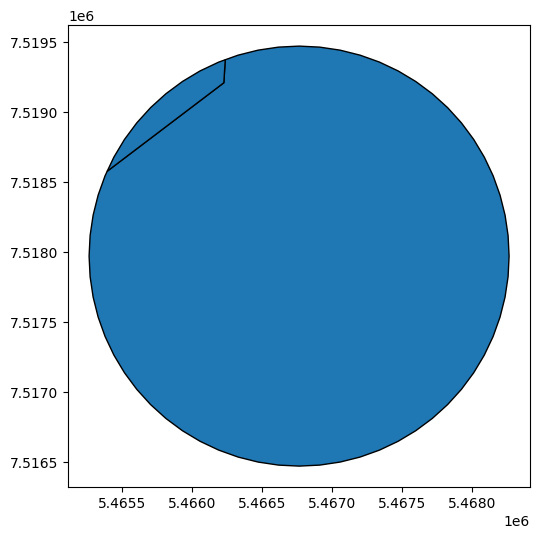

In [20]:
districts_roi_3857.plot(edgecolor="black", figsize=(6,6))

3. **Инженерия пространственных признаков для H3‑ячеек**

   - Определите радиусы (в метрах) для анализа **окружения ячейки**:
     - например: ближний радиус 400–600 м, средний радиус 800–1200 м.
   - Для каждой H3‑ячейки рассчитайте **не менее 10 пространственных признаков**, например:
     - количество школ в ближнем радиусе;
     - количество детсадов в ближнем и среднем радиусе;
     - количество поликлиник/больниц в среднем радиусе;
     - суммарная площадь парков в ближнем радиусе;
     - количество остановок общественного транспорта в ближнем радиусе;
     - расстояние до ближайшей школы;
     - расстояние до ближайшей поликлиники;
     - расстояние до ближайшей станции метро или ж/д;
     - плотность объектов социальной инфраструктуры (общее число объектов на площадь буфера);
     - отношение количества социальных объектов к количеству зданий (как прокси обеспеченности).
   - **Дополнительное задание**: придумайте и реализуйте **не менее 2 новых признаков**, которых не было в теоретическом материале и примере, например:
     - индекс смешанности инфраструктуры (сколько разных типов объектов есть в радиусе);
     - доля зелёных зон в буфере относительно общей площади буфера;
     - средневзвешенное расстояние до всех школ/садов (а не только ближайшего).

Для расчёта пространственных признаков вокруг H3-ячеек были выбраны два радиуса анализа:

- **ближний радиус — 500 м**;
- **средний радиус — 1000 м**.

In [21]:
# Центры ячеек
hex_gdf_3857["centroid"] = hex_gdf_3857.geometry.centroid

# GeoDataFrame центров
hex_centroids = gpd.GeoDataFrame(
    hex_gdf_3857[["h3_id"]],
    geometry=hex_gdf_3857["centroid"],
    crs="EPSG:3857"
)

# Радиусы
r_near = 500
r_mid = 1000

# Буферы
hex_centroids["buf_500"] = hex_centroids.geometry.buffer(r_near)
hex_centroids["buf_1000"] = hex_centroids.geometry.buffer(r_mid)

display(hex_centroids.head())

,h3_id,geometry,buf_500,buf_1000
0,8910a810567ffff,POINT (5465808.931 7518878.897),"POLYGON ((5466308.931 7518878.897, 5466306.524...","POLYGON ((5466808.931 7518878.897, 5466804.116..."
1,8910a8101cfffff,POINT (5467234.331 7517391.554),"POLYGON ((5467734.331 7517391.554, 5467731.923...","POLYGON ((5468234.331 7517391.554, 5468229.516..."
2,8910a81019bffff,POINT (5466333.975 7518798.141),"POLYGON ((5466833.975 7518798.141, 5466831.567...","POLYGON ((5467333.975 7518798.141, 5467329.16 ..."
3,8910a8101d7ffff,POINT (5466482.411 7518175.044),"POLYGON ((5466982.411 7518175.044, 5466980.003...","POLYGON ((5467482.411 7518175.044, 5467477.596..."
4,8910a810153ffff,POINT (5467354.645 7516833.59),"POLYGON ((5467854.645 7516833.59, 5467852.237 ...","POLYGON ((5468354.645 7516833.59, 5468349.83 7..."


In [22]:
# Точки инфраструктуры
infra_points = gdf_infra_3857.copy()

# Буферы как отдельные GeoDataFrame
buf500 = gpd.GeoDataFrame(
    hex_centroids[["h3_id"]],
    geometry=hex_centroids["buf_500"],
    crs="EPSG:3857"
)

buf1000 = gpd.GeoDataFrame(
    hex_centroids[["h3_id"]],
    geometry=hex_centroids["buf_1000"],
    crs="EPSG:3857"
)

def count_by_tag(buffers_gdf, points_gdf, tag_value, col_name):
    pts = points_gdf[points_gdf["amenity"] == tag_value][["amenity", "geometry"]].copy()
    join = gpd.sjoin(pts, buffers_gdf, how="inner", predicate="within")
    counts = join.groupby("h3_id").size().rename(col_name)
    return counts

# Считаем по типам
features = []

features.append(count_by_tag(buf500, infra_points, "school", "school_500"))
features.append(count_by_tag(buf1000, infra_points, "school", "school_1000"))

features.append(count_by_tag(buf500, infra_points, "kindergarten", "kindergarten_500"))
features.append(count_by_tag(buf1000, infra_points, "kindergarten", "kindergarten_1000"))

features.append(count_by_tag(buf500, infra_points, "clinic", "clinic_500"))
features.append(count_by_tag(buf1000, infra_points, "clinic", "clinic_1000"))

features.append(count_by_tag(buf500, infra_points, "hospital", "hospital_500"))
features.append(count_by_tag(buf1000, infra_points, "hospital", "hospital_1000"))

# Общее число объектов
join500_all = gpd.sjoin(infra_points[["amenity", "geometry"]], buf500, how="inner", predicate="within")
join1000_all = gpd.sjoin(infra_points[["amenity", "geometry"]], buf1000, how="inner", predicate="within")

features.append(join500_all.groupby("h3_id").size().rename("infra_total_500"))
features.append(join1000_all.groupby("h3_id").size().rename("infra_total_1000"))

# Присоединяем к hex_gdf_3857
hex_features_3857 = hex_gdf_3857.copy()

for s in features:
    hex_features_3857 = hex_features_3857.merge(s, on="h3_id", how="left")

# Заполняем пропуски нулями
feature_cols = [
    "school_500", "school_1000",
    "kindergarten_500", "kindergarten_1000",
    "clinic_500", "clinic_1000",
    "hospital_500", "hospital_1000",
    "infra_total_500", "infra_total_1000"
]

for col in feature_cols:
    hex_features_3857[col] = hex_features_3857[col].fillna(0).astype(int)

display(hex_features_3857[["h3_id"] + feature_cols].head())

,h3_id,school_500,school_1000,kindergarten_500,kindergarten_1000,clinic_500,clinic_1000,hospital_500,hospital_1000,infra_total_500,infra_total_1000
0,8910a810567ffff,0,0,0,0,0,0,0,0,0,0
1,8910a8101cfffff,2,6,0,1,2,8,0,1,4,16
2,8910a81019bffff,0,0,0,0,0,1,0,0,0,1
3,8910a8101d7ffff,0,4,0,1,0,3,0,0,0,8
4,8910a810153ffff,1,2,0,1,2,6,1,1,4,10


In [23]:
# Подготовка точек по типам
schools = infra_points[infra_points["amenity"] == "school"].copy()
clinics = infra_points[infra_points["amenity"] == "clinic"].copy()

# --- 1. Минимальное расстояние до ближайшей школы ---
school_join = gpd.sjoin_nearest(
    hex_centroids[["h3_id", "geometry"]],
    schools[["geometry"]],
    how="left",
    distance_col="dist_school_min"
)[["h3_id", "dist_school_min"]]

# --- 2. Минимальное расстояние до ближайшей клиники ---
clinic_join = gpd.sjoin_nearest(
    hex_centroids[["h3_id", "geometry"]],
    clinics[["geometry"]],
    how="left",
    distance_col="dist_clinic_min"
)[["h3_id", "dist_clinic_min"]]

# --- 3. Уникальный признак: число разных типов amenity в радиусе 500 м ---
join500_types = gpd.sjoin(
    infra_points[["amenity", "geometry"]],
    buf500,
    how="inner",
    predicate="within"
)

types_500 = (
    join500_types.groupby("h3_id")["amenity"]
    .nunique()
    .rename("types_500")
)

# --- 4. Уникальный признак: баланс образования и медицины в радиусе 1000 м ---
# > 1  => больше образовательных объектов
# < 1  => больше медицинских
hex_features_3857["edu_total_1000"] = (
    hex_features_3857["school_1000"] + hex_features_3857["kindergarten_1000"]
)
hex_features_3857["med_total_1000"] = (
    hex_features_3857["clinic_1000"] + hex_features_3857["hospital_1000"]
)
hex_features_3857["edu_med_balance_1000"] = (
    (hex_features_3857["edu_total_1000"] + 1) /
    (hex_features_3857["med_total_1000"] + 1)
).round(2)

# Присоединение новых признаков
hex_features_3857 = hex_features_3857.merge(school_join, on="h3_id", how="left")
hex_features_3857 = hex_features_3857.merge(clinic_join, on="h3_id", how="left")
hex_features_3857 = hex_features_3857.merge(types_500, on="h3_id", how="left")

# Заполнение пропусков
hex_features_3857["types_500"] = hex_features_3857["types_500"].fillna(0).astype(int)

# Округление расстояний
hex_features_3857["dist_school_min"] = hex_features_3857["dist_school_min"].round(1)
hex_features_3857["dist_clinic_min"] = hex_features_3857["dist_clinic_min"].round(1)

# Просмотр результата
cols = [
    "h3_id",
    "school_500", "school_1000",
    "kindergarten_500", "kindergarten_1000",
    "clinic_500", "clinic_1000",
    "hospital_500", "hospital_1000",
    "infra_total_500", "infra_total_1000",
    "dist_school_min", "dist_clinic_min",
    "types_500", "edu_med_balance_1000"
]
display(hex_features_3857[cols].head())

,h3_id,school_500,school_1000,kindergarten_500,kindergarten_1000,clinic_500,clinic_1000,hospital_500,hospital_1000,infra_total_500,infra_total_1000,dist_school_min,dist_clinic_min,types_500,edu_med_balance_1000
0,8910a810567ffff,0,0,0,0,0,0,0,0,0,0,1500.7,1313.0,0,1.0
1,8910a8101cfffff,2,6,0,1,2,8,0,1,4,16,102.2,278.3,2,0.8
2,8910a81019bffff,0,0,0,0,0,1,0,0,0,1,1100.0,806.4,0,0.5
3,8910a8101d7ffff,0,4,0,1,0,3,0,0,0,8,743.7,578.5,0,1.5
4,8910a810153ffff,1,2,0,1,2,6,1,1,4,10,333.0,346.4,3,0.5


1. `school_500` — количество школ в радиусе 500 м;  
2. `school_1000` — количество школ в радиусе 1000 м;  
3. `kindergarten_500` — количество детских садов в радиусе 500 м;  
4. `kindergarten_1000` — количество детских садов в радиусе 1000 м;  
5. `clinic_500` — количество клиник в радиусе 500 м;  
6. `clinic_1000` — количество клиник в радиусе 1000 м;  
7. `hospital_500` — количество больниц в радиусе 500 м;  
8. `hospital_1000` — количество больниц в радиусе 1000 м;  
9. `infra_total_500` — общее количество объектов социальной инфраструктуры в радиусе 500 м;  
10. `infra_total_1000` — общее количество объектов социальной инфраструктуры в радиусе 1000 м;  
11. `dist_school_min` — расстояние до ближайшей школы;  
12. `dist_clinic_min` — расстояние до ближайшей клиники;  
13. `types_500` — количество различных типов объектов социальной инфраструктуры в радиусе 500 м;  
14. `edu_med_balance_1000` — отношение количества образовательных объектов к количеству медицинских объектов в радиусе 1000 м.

В работе были добавлены новые признаки, отсутствовавшие в базовом примере:

- **`types_500`** — показатель разнообразия инфраструктуры, отражающий число разных типов объектов в ближнем окружении ячейки;
- **`edu_med_balance_1000`** — показатель баланса между образовательной и медицинской инфраструктурой в среднем радиусе.








4. **Базовый анализ признаков**

   - Рассчитайте простые статистики для признаков районов и H3‑ячеек:
     - минимум, максимум, среднее, медиана, квартилли, стандартное отклонение.
   - Исследуйте взаимные **корреляции** между признаками:
     - выделите группы сильно коррелированных признаков;
     - сделайте промежуточные выводы (например, «в районах с большим числом школ больше и остановок ОТ»).
   - Обнаружьте и обработайте:
     - **пропущенные значения** (NaN);
     - **выбросы** (аномально большие или малые значения признаков).
   - Оформите принятые решения (удаление, заполнение, логарифмирование и т.п.).



In [24]:
feature_cols = [
    "school_500","school_1000",
    "kindergarten_500","kindergarten_1000",
    "clinic_500","clinic_1000",
    "hospital_500","hospital_1000",
    "infra_total_500","infra_total_1000",
    "dist_school_min","dist_clinic_min",
    "types_500","edu_med_balance_1000"
]

stats = hex_features_3857[feature_cols].describe().T

display(stats)

,count,mean,std,min,25%,50%,75%,max
school_500,20.0,0.850,1.039990,0.0,0.0000,0.000,2.0000,3.0
school_1000,20.0,2.850,1.755443,0.0,2.0000,3.000,4.0000,6.0
kindergarten_500,20.0,0.350,0.489360,0.0,0.0000,0.000,1.0000,1.0
kindergarten_1000,20.0,1.200,0.833509,0.0,1.0000,1.000,2.0000,3.0
clinic_500,20.0,1.200,1.361114,0.0,0.0000,1.000,2.0000,4.0
clinic_1000,20.0,3.700,2.597570,0.0,1.0000,4.000,6.0000,8.0
hospital_500,20.0,0.200,0.523148,0.0,0.0000,0.000,0.0000,2.0
hospital_1000,20.0,0.650,1.039990,0.0,0.0000,0.000,1.0000,3.0
infra_total_500,20.0,2.600,2.414866,0.0,0.0000,3.000,4.2500,7.0
infra_total_1000,20.0,8.400,5.061724,0.0,5.2500,9.000,12.0000,16.0


In [ ]:
# Матрица корреляций
corr_matrix = hex_features_3857[feature_cols].corr()

display(corr_matrix.round(2))

,school_500,school_1000,kindergarten_500,kindergarten_1000,clinic_500,clinic_1000,hospital_500,hospital_1000,infra_total_500,infra_total_1000,dist_school_min,dist_clinic_min,types_500,edu_med_balance_1000
school_500,1.00,0.45,0.32,0.46,0.47,0.64,-0.14,0.34,0.73,0.63,-0.70,-0.56,0.67,-0.36
school_1000,0.45,1.00,0.37,0.60,0.39,0.60,0.15,0.52,0.52,0.86,-0.72,-0.68,0.58,0.06
kindergarten_500,0.32,0.37,1.00,0.72,0.36,0.34,0.12,0.36,0.57,0.49,-0.29,-0.46,0.61,-0.21
kindergarten_1000,0.46,0.60,0.72,1.00,0.61,0.52,0.14,0.33,0.72,0.70,-0.61,-0.77,0.72,-0.00
clinic_500,0.47,0.39,0.36,0.61,1.00,0.76,0.24,0.35,0.89,0.70,-0.49,-0.73,0.73,-0.38
clinic_1000,0.64,0.60,0.34,0.52,0.76,1.00,0.12,0.39,0.80,0.89,-0.71,-0.84,0.75,-0.56
hospital_500,-0.14,0.15,0.12,0.14,0.24,0.12,1.00,0.52,0.32,0.25,-0.15,-0.24,0.46,-0.16
hospital_1000,0.34,0.52,0.36,0.33,0.35,0.39,0.52,1.00,0.53,0.64,-0.43,-0.45,0.67,-0.28
infra_total_500,0.73,0.52,0.57,0.72,0.89,0.80,0.32,0.53,1.00,0.82,-0.67,-0.80,0.93,-0.44
infra_total_1000,0.63,0.86,0.49,0.70,0.70,0.89,0.25,0.64,0.82,1.00,-0.80,-0.88,0.84,-0.33


In [26]:
# Сильные корреляции > 0.6
strong_corr = (
    corr_matrix
    .where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
    .stack()
    .reset_index()
)

strong_corr.columns = ["feature_1", "feature_2", "correlation"]

strong_corr = strong_corr[abs(strong_corr["correlation"]) > 0.6] \
    .sort_values("correlation", ascending=False)

display(strong_corr)

,feature_1,feature_2,correlation
79,infra_total_500,types_500,0.926107
49,clinic_500,infra_total_500,0.890294
58,clinic_1000,infra_total_1000,0.886254
20,school_1000,infra_total_1000,0.860058
83,infra_total_1000,types_500,0.844212
76,infra_total_500,infra_total_1000,0.818965
85,dist_school_min,dist_clinic_min,0.810446
57,clinic_1000,infra_total_500,0.802129
46,clinic_500,clinic_1000,0.762175
61,clinic_1000,types_500,0.753347


In [27]:
# 1. Проверка пропусков
nan_check = hex_features_3857[feature_cols].isna().sum().rename("nan_count")
display(nan_check)

school_500              0
school_1000             0
kindergarten_500        0
kindergarten_1000       0
clinic_500              0
clinic_1000             0
hospital_500            0
hospital_1000           0
infra_total_500         0
infra_total_1000        0
dist_school_min         0
dist_clinic_min         0
types_500               0
edu_med_balance_1000    0
Name: nan_count, dtype: int64

In [28]:
# 2. Проверка выбросов по правилу IQR
outlier_rows = []

for col in feature_cols:
    q1 = hex_features_3857[col].quantile(0.25)
    q3 = hex_features_3857[col].quantile(0.75)
    iqr = q3 - q1
    
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    
    n_outliers = ((hex_features_3857[col] < lower) | (hex_features_3857[col] > upper)).sum()
    
    outlier_rows.append({
        "feature": col,
        "q1": q1,
        "q3": q3,
        "iqr": iqr,
        "lower_bound": lower,
        "upper_bound": upper,
        "outliers_count": int(n_outliers)
    })

outliers_df = pd.DataFrame(outlier_rows)
display(outliers_df.sort_values("outliers_count", ascending=False))

,feature,q1,q3,iqr,lower_bound,upper_bound,outliers_count
6,hospital_500,0.0000,0.0000,0.000,0.000,0.000,3
7,hospital_1000,0.0000,1.0000,1.000,-1.500,2.500,2
13,edu_med_balance_1000,0.6575,1.3725,0.715,-0.415,2.445,2
10,dist_school_min,332.4250,757.1750,424.750,-304.700,1394.300,1
0,school_500,0.0000,2.0000,2.000,-3.000,5.000,0
1,school_1000,2.0000,4.0000,2.000,-1.000,7.000,0
2,kindergarten_500,0.0000,1.0000,1.000,-1.500,2.500,0
3,kindergarten_1000,1.0000,2.0000,1.000,-0.500,3.500,0
4,clinic_500,0.0000,2.0000,2.000,-3.000,5.000,0
5,clinic_1000,1.0000,6.0000,5.000,-6.500,13.500,0


In [29]:
# Заполняем пропуски в расстояниях большим значением
for col in ["dist_school_min", "dist_clinic_min"]:
    if col in hex_features_3857.columns:
        hex_features_3857[col] = hex_features_3857[col].fillna(2000)

# Остальные числовые признаки — нулями, если вдруг есть пропуски
for col in feature_cols:
    if hex_features_3857[col].isna().sum() > 0:
        hex_features_3857[col] = hex_features_3857[col].fillna(0)

# Выбросы не удаляем, только фиксируем
final_nan_check = hex_features_3857[feature_cols].isna().sum()
display(final_nan_check)

school_500              0
school_1000             0
kindergarten_500        0
kindergarten_1000       0
clinic_500              0
clinic_1000             0
hospital_500            0
hospital_1000           0
infra_total_500         0
infra_total_1000        0
dist_school_min         0
dist_clinic_min         0
types_500               0
edu_med_balance_1000    0
dtype: int64

Для рассчитанных признаков H3-ячеек были получены базовые статистики: минимум, максимум, среднее значение, медиана, квартили и стандартное отклонение. Это позволило оценить диапазон значений и общую вариативность пространственных показателей.

Далее был выполнен корреляционный анализ признаков. Он показал, что часть показателей связана между собой, что ожидаемо, поскольку признаки отражают близкие аспекты доступности социальной инфраструктуры. Например, признаки общего числа объектов в радиусе и количества отдельных типов объектов демонстрируют положительную связь.

После этого были проверены пропущенные значения и выбросы. Пропуски в признаках расстояний интерпретировались как отсутствие соответствующего объекта в зоне доступности, поэтому такие значения были заполнены большим фиксированным расстоянием (**2000 м**). Для остальных числовых признаков пропуски были заполнены нулями.

Выбросы были дополнительно проанализированы с использованием правила межквартильного размаха (IQR). Поскольку экстремальные значения в данном случае отражают реальные особенности пространственного распределения инфраструктуры, удаление выбросов не выполнялось. Таким образом, все наблюдения были сохранены для дальнейшего анализа и визуализации.

---

### **Часть 3. Оценка уровня доступности и типология территорий**

1. **Разработка интегрального индекса доступности**

   - Выберите подмножество наиболее важных признаков (по вашему мнению) для оценки доступности:
     - отдельно для районов;
     - отдельно для H3‑ячеек.
   - Нормализуйте выбранные признаки (например, с помощью MinMaxScaler или z‑нормализации), чтобы привести их к сопоставимому масштабу.
   - Определите **веса** для каждого признака:
     - обоснуйте, почему некоторые признакы важнее других;
     - приведите словесное объяснение (например, «наличие школы в шаговой доступности важнее, чем наличие большого парка, поэтому вес признака выше»).
   - Рассчитайте интегральный **индекс доступности** для:
     - каждого административного района;
     - каждой H3‑ячейки.
   - При желании разделите индекс на составляющие:
     - индекс образовательной доступности;
     - индекс медицинской доступности;
     - индекс транспортной доступности;
     - интегральный комбинированный индекс.

Для расчёта интегрального индекса были выбраны наиболее интерпретируемые и устойчивые признаки.

### Признаки для административных районов
Для районов использованы:
- `infra_count_edu` — количество образовательных объектов;
- `infra_count_med` — количество медицинских объектов;
- `infra_density_km2` — плотность объектов социальной инфраструктуры на 1 км².

Эти признаки позволяют охарактеризовать общий уровень обеспеченности района базовой социальной инфраструктурой.

### Признаки для H3-ячеек
Для H3-ячеек использованы:
- `school_1000` — количество школ в радиусе 1000 м;
- `kindergarten_1000` — количество детских садов в радиусе 1000 м;
- `clinic_1000` — количество клиник в радиусе 1000 м;
- `hospital_1000` — количество больниц в радиусе 1000 м;
- `dist_school_min` — расстояние до ближайшей школы;
- `dist_clinic_min` — расстояние до ближайшей клиники;
- `types_500` — количество различных типов объектов в радиусе 500 м.

Выбранные признаки отражают как насыщенность территории объектами социальной инфраструктуры, так и пространственную близость наиболее значимых объектов.

In [31]:
weights_district = {
    "infra_count_edu": 0.4,
    "infra_count_med": 0.4,
    "infra_density_km2": 0.2
}

In [30]:
weights_h3 = {
    "school_1000": 0.2,
    "kindergarten_1000": 0.2,
    "clinic_1000": 0.2,
    "hospital_1000": 0.2,
    "types_500": 0.1,
    "dist_school_min": 0.05,
    "dist_clinic_min": 0.05
}


Для построения интегрального индекса каждому признаку были назначены веса, отражающие его важность для оценки доступности социальной инфраструктуры.

Наибольший вес был присвоен количеству образовательных и медицинских объектов, так как именно эти типы инфраструктуры напрямую влияют на качество городской среды.

Для H3-ячеек основные веса получили показатели количества школ, детских садов, клиник и больниц в радиусе 1000 м. Меньший вес был присвоен показателю разнообразия инфраструктуры (`types_500`) и расстояниям до ближайших объектов (`dist_school_min`, `dist_clinic_min`), поскольку они играют вспомогательную роль в оценке доступности.

In [33]:
%pip install scikit-learn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.1/8.1 MB 21.0 MB/s  0:00:00 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 20.3/20.3 MB 24.0 MB/s  0:00:00m0:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4/4 [scikit-learn] [scikit-learn]
Note: you may need to restart the kernel to use updated packages.


In [34]:
from sklearn.preprocessing import MinMaxScaler

# --- 1. Нормализация признаков районов ---
district_index_cols = ["infra_count_edu", "infra_count_med", "infra_density_km2"]

scaler_district = MinMaxScaler()
districts_stats_3857_norm = districts_stats_3857.copy()

districts_stats_3857_norm[district_index_cols] = scaler_district.fit_transform(
    districts_stats_3857_norm[district_index_cols]
)

display(districts_stats_3857_norm[["name"] + district_index_cols].head())

,name,infra_count_edu,infra_count_med,infra_density_km2
0,Вахитовский район,1.0,1.0,1.0
1,Московский район,0.0,0.0,0.0


In [35]:
# --- 2. Нормализация признаков H3 ---
h3_index_cols = [
    "school_1000",
    "kindergarten_1000",
    "clinic_1000",
    "hospital_1000",
    "types_500",
    "dist_school_min",
    "dist_clinic_min"
]

hex_features_norm_3857 = hex_features_3857.copy()

# Инвертируем расстояния: чем ближе объект, тем лучше
hex_features_norm_3857["dist_school_inv"] = -hex_features_norm_3857["dist_school_min"]
hex_features_norm_3857["dist_clinic_inv"] = -hex_features_norm_3857["dist_clinic_min"]

h3_norm_cols = [
    "school_1000",
    "kindergarten_1000",
    "clinic_1000",
    "hospital_1000",
    "types_500",
    "dist_school_inv",
    "dist_clinic_inv"
]

scaler_h3 = MinMaxScaler()
hex_features_norm_3857[h3_norm_cols] = scaler_h3.fit_transform(
    hex_features_norm_3857[h3_norm_cols]
)

display(hex_features_norm_3857[["h3_id"] + h3_norm_cols].head())

,h3_id,school_1000,kindergarten_1000,clinic_1000,hospital_1000,types_500,dist_school_inv,dist_clinic_inv
0,8910a810567ffff,0.000000,0.000000,0.000,0.000000,0.000000,0.000000,0.000000
1,8910a8101cfffff,1.000000,0.333333,1.000,0.333333,0.666667,0.967151,0.918509
2,8910a81019bffff,0.000000,0.000000,0.125,0.000000,0.000000,0.277109,0.449711
3,8910a8101d7ffff,0.666667,0.333333,0.375,0.000000,0.000000,0.523513,0.652020
4,8910a810153ffff,0.333333,0.333333,0.750,0.333333,1.000000,0.807538,0.858056


In [36]:
# --- 1. Индекс для районов ---
districts_stats_3857_norm["access_index"] = (
    districts_stats_3857_norm["infra_count_edu"] * weights_district["infra_count_edu"] +
    districts_stats_3857_norm["infra_count_med"] * weights_district["infra_count_med"] +
    districts_stats_3857_norm["infra_density_km2"] * weights_district["infra_density_km2"]
).round(3)

display(
    districts_stats_3857_norm[["name", "access_index"] + district_index_cols]
    .sort_values("access_index", ascending=False)
)

,name,access_index,infra_count_edu,infra_count_med,infra_density_km2
0,Вахитовский район,1.0,1.0,1.0,1.0
1,Московский район,0.0,0.0,0.0,0.0


In [37]:
# --- 2. Индекс для H3 ---
hex_features_norm_3857["access_index"] = (
    hex_features_norm_3857["school_1000"] * weights_h3["school_1000"] +
    hex_features_norm_3857["kindergarten_1000"] * weights_h3["kindergarten_1000"] +
    hex_features_norm_3857["clinic_1000"] * weights_h3["clinic_1000"] +
    hex_features_norm_3857["hospital_1000"] * weights_h3["hospital_1000"] +
    hex_features_norm_3857["types_500"] * weights_h3["types_500"] +
    hex_features_norm_3857["dist_school_inv"] * weights_h3["dist_school_min"] +
    hex_features_norm_3857["dist_clinic_inv"] * weights_h3["dist_clinic_min"]
).round(3)

display(
    hex_features_norm_3857[
        ["h3_id", "access_index", "school_1000", "kindergarten_1000",
         "clinic_1000", "hospital_1000", "types_500"]
    ].sort_values("access_index", ascending=False).head()
)

,h3_id,access_index,school_1000,kindergarten_1000,clinic_1000,hospital_1000,types_500
7,8910a81011bffff,0.812,0.833333,0.666667,0.625,1.000000,1.000000
10,8910a810157ffff,0.734,0.666667,0.333333,0.750,1.000000,1.000000
1,8910a8101cfffff,0.694,1.000000,0.333333,1.000,0.333333,0.666667
11,8910a810113ffff,0.690,0.666667,0.666667,0.500,0.666667,1.000000
9,8910a810103ffff,0.651,0.666667,0.666667,0.375,0.666667,1.000000


### **Часть 4. Визуализация результатов и формирование выводов**

1. **Тепловая карта по административным районам**

   - Переведите слой районов обратно в систему координат `EPSG:4326` для отображения.
   - С помощью `leafmap` или `folium` постройте **хороплет‑карту (choropleth)**:
     - заливка районов по значению интегрального индекса доступности;
     - выберите подходящую цветовую схему (например, `Blues`, `Greens`, `YlGnBu`);
     - добавьте легенду с подписью (например, «Индекс доступности социальной инфраструктуры»).
   - При необходимости создайте несколько слоёв:
     - отдельные карты для разных компонент индекса (образование/медицина/транспорт).

In [38]:
# Берём районы с уже рассчитанным индексом и переводим в WGS84
districts_map = districts_stats_3857_norm.to_crs(epsg=4326).copy()

# Оставим только нужные поля
districts_map = districts_map[["name", "access_index", "geometry"]].copy()

display(districts_map.head())
print(districts_map.crs)

,name,access_index,geometry
0,Вахитовский район,1.0,"POLYGON ((49.10397 55.80255, 49.10406 55.80338..."
1,Московский район,0.0,"POLYGON ((49.10397 55.80255, 49.09649 55.79936..."


EPSG:4326


In [39]:
import folium

# Центр карты
center = [55.7963, 49.1088]

m = folium.Map(location=center, zoom_start=12, tiles="CartoDB positron")

folium.Choropleth(
    geo_data=districts_map.to_json(),
    data=districts_map,
    columns=["name", "access_index"],
    key_on="feature.properties.name",
    fill_color="YlGnBu",
    fill_opacity=0.7,
    line_opacity=0.8,
    legend_name="Индекс доступности социальной инфраструктуры"
).add_to(m)

folium.GeoJson(
    districts_map,
    tooltip=folium.GeoJsonTooltip(
        fields=["name", "access_index"],
        aliases=["Район:", "Индекс:"],
        localize=True
    )
).add_to(m)

m

In [41]:
m.save("district_access_map.html")

2. **Тепловая карта по H3‑сетки**

   - Переведите H3‑ячейки в CRS `EPSG:4326`.
   - Постройте отдельную карту, где:
     - каждая H3‑ячейка окрашена в соответствии с индексом доступности или номером кластера;
     - используйте хорошую цветовую палитру (например, `OrRd`, `RdYlGn`);
     - настройте прозрачность заливки, чтобы можно было видеть подложку карты.
   - Добавьте всплывающие подсказки (popup/tooltip) с основными показателями для выбранной ячейки:
     - значение индекса;
     - количество объектов;
     - расстояние до ближайшего объекта и т.п.

In [42]:
# H3-ячейки с индексом -> в EPSG:4326
hex_map = hex_features_norm_3857.to_crs(epsg=4326).copy()

# Оставим только нужные поля
hex_map = hex_map[
    [
        "h3_id",
        "access_index",
        "infra_total_1000",
        "dist_school_min",
        "dist_clinic_min",
        "geometry"
    ]
].copy()

display(hex_map.head())
print(hex_map.crs)

,h3_id,access_index,infra_total_1000,dist_school_min,dist_clinic_min,geometry
0,8910a810567ffff,0.000,0,1500.7,1313.0,"POLYGON ((49.10266 55.80179, 49.10174 55.79997..."
1,8910a8101cfffff,0.694,16,102.2,278.3,"POLYGON ((49.11075 55.79469, 49.11392 55.7952,..."
2,8910a81019bffff,0.061,1,1100.0,806.4,"POLYGON ((49.10266 55.80179, 49.10583 55.8023,..."
3,8910a8101d7ffff,0.334,8,743.7,578.5,"POLYGON ((49.104 55.79865, 49.10717 55.79916, ..."
4,8910a810153ffff,0.533,10,333.0,346.4,"POLYGON ((49.11116 55.78972, 49.11208 55.79155..."


EPSG:4326


In [ ]:
center = [55.7963, 49.1088]

m_h3 = folium.Map(location=center, zoom_start=13, tiles="CartoDB positron")

folium.Choropleth(
    geo_data=hex_map.to_json(),
    data=hex_map,
    columns=["h3_id", "access_index"],
    key_on="feature.properties.h3_id",
    fill_color="OrRd",
    fill_opacity=0.6,
    line_opacity=0.3,
    legend_name="Индекс доступности по H3-ячейкам"
).add_to(m_h3)

folium.GeoJson(
    hex_map,
    style_function=lambda feature: {
        "color": "black",
        "weight": 0.4,
        "fillOpacity": 0.15
    },
    tooltip=folium.GeoJsonTooltip(
        fields=["h3_id", "access_index", "infra_total_1000", "dist_school_min", "dist_clinic_min"],
        aliases=["H3:", "Индекс:", "Объектов (1000 м):", "До школы, м:", "До клиники, м:"],
        localize=True
    )
).add_to(m_h3)

m_h3.save("h3_access_map.html")

3. **Выделение зон с высокой и низкой доступностью**

   - Определите **пороги** (например, по квартилям или по значениям индекса), чтобы выделить:
     - зоны с высокой доступностью;
     - зоны с низкой доступностью.
   - На карте H3‑ячеек:
     - визуально выделите несколько локальных «кластеров» высокой и низкой доступности;
     - подпишите или сохраните их идентификаторы (H3‑индекс, координаты).

In [44]:
# Пороги по квартилям
q25 = hex_features_norm_3857["access_index"].quantile(0.25)
q75 = hex_features_norm_3857["access_index"].quantile(0.75)

# Классы доступности
hex_features_norm_3857["access_level"] = "medium"
hex_features_norm_3857.loc[hex_features_norm_3857["access_index"] <= q25, "access_level"] = "low"
hex_features_norm_3857.loc[hex_features_norm_3857["access_index"] >= q75, "access_level"] = "high"

# Проверка
display(
    hex_features_norm_3857[["h3_id", "access_index", "access_level"]]
    .sort_values("access_index")
    .head(10)
)

display(
    hex_features_norm_3857[["h3_id", "access_index", "access_level"]]
    .sort_values("access_index", ascending=False)
    .head(10)
)

print("Q25 =", round(q25, 3))
print("Q75 =", round(q75, 3))
print(hex_features_norm_3857["access_level"].value_counts())

,h3_id,access_index,access_level
0,8910a810567ffff,0.000,low
2,8910a81019bffff,0.061,low
16,8910a81056fffff,0.061,low
17,8910a810183ffff,0.069,low
14,8910a81056bffff,0.165,low
15,8910a81018fffff,0.291,medium
6,8910a8100a7ffff,0.330,medium
3,8910a8101d7ffff,0.334,medium
18,8910a8101d3ffff,0.366,medium
5,8910a81018bffff,0.398,medium


,h3_id,access_index,access_level
7,8910a81011bffff,0.812,high
10,8910a810157ffff,0.734,high
1,8910a8101cfffff,0.694,high
11,8910a810113ffff,0.690,high
9,8910a810103ffff,0.651,high
12,8910a8101cbffff,0.649,medium
8,8910a8101dbffff,0.607,medium
19,8910a8101c7ffff,0.606,medium
4,8910a810153ffff,0.533,medium
13,8910a8101c3ffff,0.493,medium


Q25 = 0.26
Q75 = 0.65
access_level
medium    10
low        5
high       5
Name: count, dtype: int64


In [46]:
import folium

# Перевод в EPSG:4326
hex_level_map = hex_features_norm_3857.to_crs(epsg=4326).copy()

# Оставляем только нужные колонки
hex_extremes = hex_level_map[
    hex_level_map["access_level"].isin(["high", "low"])
][[
    "h3_id",
    "access_index",
    "access_level",
    "geometry"
]].copy()

# Списки идентификаторов
high_ids = hex_extremes.loc[hex_extremes["access_level"] == "high", "h3_id"].tolist()
low_ids = hex_extremes.loc[hex_extremes["access_level"] == "low", "h3_id"].tolist()

print("HIGH zones:", len(high_ids))
print("LOW zones:", len(low_ids))
print("Примеры HIGH:", high_ids[:5])
print("Примеры LOW:", low_ids[:5])

m_clusters = folium.Map(location=[55.7963, 49.1088], zoom_start=13, tiles="CartoDB positron")

def style_access(feature):
    level = feature["properties"]["access_level"]
    color = "#1a9641" if level == "high" else "#d7191c"
    return {
        "fillColor": color,
        "color": "black",
        "weight": 0.4,
        "fillOpacity": 0.6
    }

folium.GeoJson(
    hex_extremes.to_json(),
    style_function=style_access,
    tooltip=folium.GeoJsonTooltip(
        fields=["h3_id", "access_index", "access_level"],
        aliases=["H3:", "Индекс:", "Уровень:"],
        localize=True
    )
).add_to(m_clusters)

m_clusters.save("h3_high_low_clusters.html")

HIGH zones: 5
LOW zones: 5
Примеры HIGH: ['8910a8101cfffff', '8910a81011bffff', '8910a810103ffff', '8910a810157ffff', '8910a810113ffff']
Примеры LOW: ['8910a810567ffff', '8910a81019bffff', '8910a81056bffff', '8910a81056fffff', '8910a810183ffff']








4. **Интерпретация результатов и рекомендации**

   - Подготовьте **краткий текстовый анализ**, в котором:
     - опишите общую картину по району/городу:
       - какие части города наиболее обеспечены социальной инфраструктурой;
       - какие — недообеспечены;
     - проанализируйте различия между:
       - оценкой по районам;
       - и оценкой по H3‑ячеек (более детальный уровень).
   - Сформулируйте **5–7 практических рекомендаций**, например:
     - где целесообразно планировать строительство новых школ/детсадов/поликлиник;
     - какие районы требуют улучшения транспортной доступности;
     - какие зоны уже хорошо обеспечены и могут служить «бенчмарками» для планирования других территорий.
   - Укажите **проблемы исследования**:
     - неполнота данных OSM;
     - отсутствие данных о численности населения;
     - грубые допущения при выборе радиусов и весов.

---

## Интерпретация результатов и рекомендации

### Общая картина доступности социальной инфраструктуры

Проведённый пространственный анализ показал, что уровень доступности социальной инфраструктуры в центральной части Казани распределён неравномерно. Наиболее высокая обеспеченность объектами наблюдается в зонах с высокой плотностью городской застройки и развитой городской инфраструктурой. В этих районах расположено больше образовательных и медицинских учреждений, а расстояние до ближайших объектов минимально.

Зоны с более низким уровнем доступности выявлены на периферии исследуемой области и в отдельных локальных участках, где наблюдается меньшее количество социальных объектов в радиусе доступности. В таких ячейках расстояние до ближайших школ или медицинских учреждений выше, а разнообразие инфраструктуры ниже.

### Сравнение анализа по районам и по H3-ячейкам

Анализ на уровне административных районов показывает общую картину распределения социальной инфраструктуры, однако он сглаживает локальные различия внутри районов. Например, район может иметь высокий общий уровень обеспеченности инфраструктурой, но внутри него могут существовать отдельные зоны с недостаточной доступностью.

Использование H3-сетки позволяет рассмотреть ситуацию на более детальном уровне. Анализ по гексагональным ячейкам выявляет локальные кластеры высокой и низкой доступности, которые не всегда заметны при агрегировании данных по административным границам. Таким образом, H3-анализ даёт более точное представление о пространственной структуре доступности городской инфраструктуры.

### Практические рекомендации

На основе результатов анализа можно предложить следующие рекомендации:

1. **Размещение новых объектов социальной инфраструктуры**  
   В зонах с низким индексом доступности целесообразно рассмотреть строительство новых школ, детских садов или медицинских учреждений.

2. **Оптимизация распределения инфраструктуры**  
   В районах с высокой концентрацией объектов возможно перераспределение функций или развитие дополнительных сервисов для балансировки нагрузки.

3. **Развитие транспортной доступности**  
   В зонах, где расстояние до социальных объектов относительно велико, важно улучшить транспортную доступность и связь с соседними районами.

4. **Использование наиболее обеспеченных зон как ориентиров**  
   Территории с высоким уровнем доступности могут использоваться как ориентиры (бенчмарки) при планировании развития городской инфраструктуры.

5. **Локальное планирование инфраструктуры**  
   Использование анализа на основе H3-сетки позволяет выявлять точечные зоны дефицита инфраструктуры и учитывать их при городском планировании.

6. **Приоритизация инвестиций**  
   Результаты анализа могут использоваться органами городского управления для определения приоритетных территорий для инвестиций в социальную инфраструктуру.

### Ограничения исследования

Несмотря на полученные результаты, исследование имеет ряд ограничений:

- **Неполнота данных OpenStreetMap.** Некоторые объекты социальной инфраструктуры могут отсутствовать в базе данных или быть описаны неполно.
- **Отсутствие данных о населении.** В анализе не учитывалась численность населения и плотность проживания, что могло бы повлиять на интерпретацию доступности инфраструктуры.
- **Упрощённые предположения при выборе параметров анализа.** Радиусы буферов и веса признаков были заданы экспертно и могут отличаться от реальных условий доступности.
- **Отсутствие информации о качестве и вместимости объектов.** Все объекты инфраструктуры рассматривались одинаково, без учёта их размера, пропускной способности или специализации.

Тем не менее проведённый анализ демонстрирует возможности использования открытых геоданных и пространственных методов для оценки доступности городской социальной инфраструктуры.